# Proyecto Final: One Anomaly, Defended
**Asignatura:** IELE756 -- Preparación y Análisis de Datos  
**Profesor:** Leo Ferres, PhD  
**Integrantes:** Javier Becerra Muñoz, Jose Pino Muñoz  
**Grupo:** Grupo 1 (La Granja, Macul, San Ramón)  

**GitHub Repository:** [Link al Repositorio de GitHub](https://github.com/javierBece/iele756-grupo01-proyecto-final/tree/main)
**Video:** [Link al Video de Drive](https://uddcl-my.sharepoint.com/:v:/g/personal/jabecerram_udd_cl/IQDAzwXkl5zfSqUnmzxdY5H1ATVLk3ml7PPV9_cWo5aQh7w?nav=eyJyZWZlcnJhbEluZm8iOnsicmVmZXJyYWxBcHAiOiJPbmVEcml2ZUZvckJ1c2luZXNzIiwicmVmZXJyYWxBcHBQbGF0Zm9ybSI6IldlYiIsInJlZmVycmFsTW9kZSI6InZpZXciLCJyZWZlcnJhbFZpZXciOiJNeUZpbGVzTGlua0NvcHkifX0&e=ECp0VB)

## 1. La Anomalía:

Durante nuestro análisis exploratorio (Tarea 3), la matriz de correlación de Pearson reveló una fuerte y contraintuitiva correlación negativa de **-0.51** entre la tasa de dependencia demográfica (`dependency_ratio`) y la tasa de desempleo a nivel comunal (`pct_unemployed`). La lógica socioeconómica dicta que las comunas con mayor dependencia (es decir, mayor proporción de niños y adultos mayores respecto a la población activa) deberían enfrentar una mayor inactividad y desempleo local, lo que se traduciría en una correlación positiva. Sin embargo, nuestros datos iniciales indicaban exactamente lo contrario: a mayor porcentaje de dependientes, menor tasa de desempleo. En este proyecto, defendemos que esta alarmante correlación negativa no es una dinámica socioeconómica real (un "milagro de empleo" en comunas familiares), sino un **artefacto matemático y un problema de integración de datos** derivado de diferencias de escala no estandarizadas en la fuerza laboral de tres comunas específicas en la base consolidada del curso.

## 2. Código de Aislamiento y Figura Principal (Headline Figure)

El siguiente bloque de código carga el dataset maestro consolidado de la Tarea 3, aísla las variables de interés, calcula la correlación de Pearson inicial y genera la **Headline Figure** que muestra la correlación negativa y los puntos atípicos extremada y económicamente imposibles.

Correlación inicial de Pearson: -0.5079


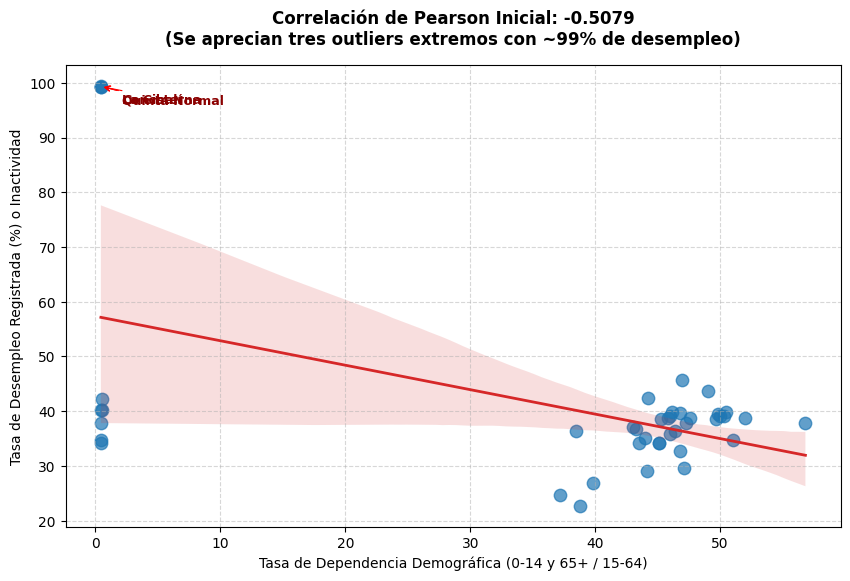

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Cargar el dataset consolidado de la Tarea 3
df_path = r"../Tarea 3/analytical_dataset_tarea3_vars.csv" # recolectamos el dataset de la Tarea 3
df = pd.read_csv(df_path) # cargamos el dataset

# 2. Calcular la correlación inicial
initial_corr = df['dependency_ratio'].corr(df['pct_unemployed']) # calculamos la correlación de Pearson entre la tasa de dependencia demográfica y la tasa de desempleo registrada
print(f"Correlación inicial de Pearson: {initial_corr:.4f}") # imprimimos la correlación inicial en consola

# 3. Configurar el gráfico
plt.figure(figsize=(10, 6)) # configuramos el tamaño del gráfico
sns.regplot( # graficamos la relación entre la tasa de dependencia demográfica y la tasa de desempleo registrada
    data=df, x='dependency_ratio', y='pct_unemployed',  # graficamos la relación entre la tasa de dependencia demográfica y la tasa de desempleo registrada
    scatter_kws={'alpha': 0.7, 'color': '#1f77b4', 's': 80}, # configuramos los puntos del scatter plot
    line_kws={'color': '#d62728', 'linewidth': 2} # configuramos la línea de regresión lineal
)

# Identificar y etiquetar comunas con desempleo mayor a 90% (Outliers)
outliers = df[df['pct_unemployed'] > 90] # filtramos el dataset para obtener solo las comunas con una tasa de desempleo mayor al 90%, que consideramos outliers extremos
for idx, row in outliers.iterrows(): # iteramos sobre las filas del dataframe de outliers para etiquetar cada comuna en el gráfico
    plt.annotate( # anotamos el nombre de la comuna en el gráfico
        row['nombre_comuna'], # el nombre de la comuna se obtiene de la columna 'nombre_comuna' del dataframe
        xy=(row['dependency_ratio'], row['pct_unemployed']), # las coordenadas del punto a etiquetar se obtienen de las columnas 'dependency_ratio' y 'pct_unemployed' del dataframe
        xytext=(15, -10), # el desplazamiento del texto respecto al punto se configura con un desplazamiento de 15 puntos a la derecha y 10 puntos hacia abajo
        textcoords='offset points', # el sistema de coordenadas para el texto se establece como 'offset points' para que el desplazamiento se aplique correctamente
        ha='left', va='center', fontsize=9, fontweight='bold', color='darkred', # configuramos la apariencia del texto de la anotación
        arrowprops=dict(arrowstyle='->', color='red', lw=0.8) # configuramos las propiedades de la flecha que conecta el texto con el punto, utilizando un estilo de flecha simple, color rojo y un ancho de línea de 0.8
    )

plt.title(f"Correlación de Pearson Inicial: {initial_corr:.4f}\n(Se aprecian tres outliers extremos con ~99% de desempleo)", fontsize=12, fontweight='bold', pad=15) # configuramos el título del gráfico para mostrar la correlación de Pearson inicial y destacar la presencia de los outliers extremos
plt.xlabel("Tasa de Dependencia Demográfica (0-14 y 65+ / 15-64)", fontsize=10) # configuramos la etiqueta del eje x para indicar que representa la tasa de dependencia demográfica, que se calcula como la proporción de personas en edad dependiente (0-14 años y 65 años o más) respecto a la población en edad laboral (15-64 años)
plt.ylabel("Tasa de Desempleo Registrada (%) o Inactividad", fontsize=10) # configuramos la etiqueta del eje y para indicar que representa la tasa de desempleo registrada o la tasa de inactividad
plt.grid(True, linestyle='--', alpha=0.5) # configuramos la cuadrícula del gráfico para mejorar la legibilidad, utilizando líneas discontinuas y una opacidad del 50%

# Crear carpeta para las figuras si no existe y guardar la Headline Figure
os.makedirs("figs", exist_ok=True) # creamos la carpeta "figs" para guardar las figuras si no existe
plt.savefig("figs/headline.png", dpi=300, bbox_inches='tight') # guardamos la figura como "headline.png" en la carpeta "figs" con una resolución de 300 dpi y ajustando los bordes para que no se recorte ningún elemento del gráfico
plt.show() # mostramos el gráfico en pantalla

## 3. Comprobación de Explicación Alternativa 1: Error de Escala e Integración de Datos (Data Scaling Bug)

**Hipótesis:** ¿Es la correlación de -0.51 un reflejo socioeconómico real de la RM, o está sesgada por errores de cálculo en la base de datos?

Al observar la Headline Figure, vemos que tres comunas (**Conchalí, La Cisterna y Quinta Normal**) muestran una tasa de desempleo del **99.3%**, lo cual es económicamente imposible. 

**La Causa Raíz:** En la Tarea 1, los grupos calcularon la tasa de empleo (`emp_rate_chilean` y `emp_rate_foreign`). Algunos grupos la subieron como fracción (rango `0-1`, p.ej. `0.61` para 61%), mientras que otros la subieron como porcentaje (rango `0-100`, p.ej. `61.0`). Al consolidar las tablas en la Tarea 3, el script del curso corrigió los desempleos negativos haciendo `100 - tasa_empleo` si detectaba valores altos, pero para las comunas cuyos datos venían en escala `0-1` (fracciones), el script ejecutó erróneamente `100 - 0.61`, resultando en un desempleo del `99.39%` (en vez de `100 * (1 - 0.61) = 39.0%`).

El siguiente código aísla estas tres comunas, corrige su escala al rango correcto (`0-100`), recalcula su desempleo y evalúa el impacto sobre la correlación general de la Región Metropolitana.

--- COMUNAS AFECTADAS POR EL ERROR DE INTEGRACIÓN ---
• Conchalí        | Registrado: 99.3693% | Corregido: 36.9344%
• La Cisterna     | Registrado: 99.3039% | Corregido: 30.3928%
• Quinta Normal   | Registrado: 99.3096% | Corregido: 30.9643%

Correlación de Pearson corregida: 0.0872


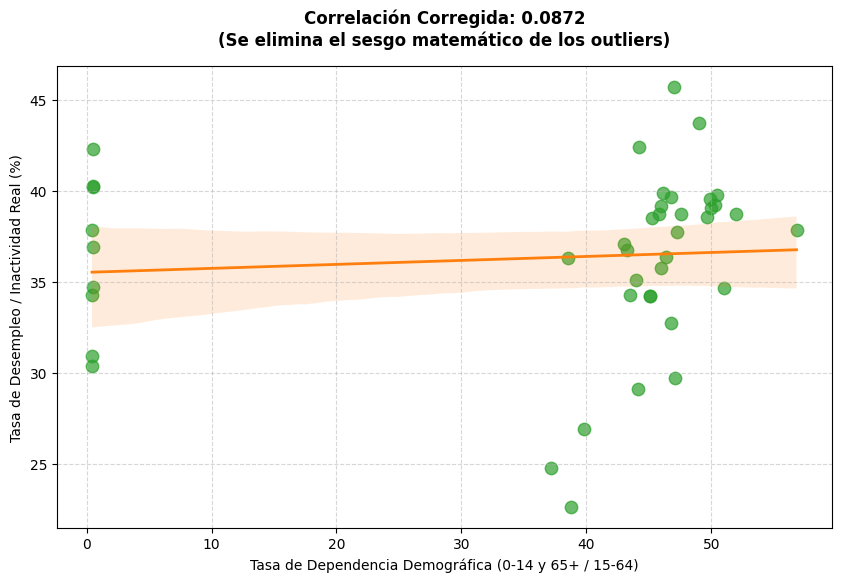

In [2]:
df_fixed = df.copy()

# 1. Identificar comunas con errores (con desempleo ficticio > 90% debido al error de fracción)
bugged_indices = df_fixed[df_fixed['pct_unemployed'] > 90].index

print("--- COMUNAS AFECTADAS POR EL ERROR DE INTEGRACIÓN ---")
for idx in bugged_indices: # iteramos sobre los índices de las comunas afectadas por el error para mostrar la corrección aplicada
    comuna = df_fixed.loc[idx, 'nombre_comuna'] # obtenemos el nombre de la comuna afectada
    val_bugged = df_fixed.loc[idx, 'pct_unemployed'] # obtenemos el valor de la tasa de desempleo registrada que está errónea (en escala 0-100)
    
    # Reconstruimos la tasa de empleo (que estaba en escala 0-1)
    tasa_empleo_fraccion = 100 - val_bugged
    # Calculamos la tasa de desempleo correcta en escala 0-100
    val_fixed = 100 * (1 - tasa_empleo_fraccion)
    
    df_fixed.loc[idx, 'pct_unemployed'] = val_fixed # corregimos el valor de la tasa de desempleo en el dataframe corregido
    print(f"• {comuna:15s} | Registrado: {val_bugged:.4f}% | Corregido: {val_fixed:.4f}%") # imprimimos en consola el nombre de la comuna, el valor registrado erróneo y el valor corregido para cada comuna afectada por el error

# 2. Calcular la nueva correlación con el dataset corregido
fixed_corr = df_fixed['dependency_ratio'].corr(df_fixed['pct_unemployed']) # calculamos la correlación de Pearson entre la tasa de dependencia demográfica y la tasa de desempleo registrada utilizando el dataset corregido
print(f"\nCorrelación de Pearson corregida: {fixed_corr:.4f}") # imprimimos la correlación corregida en consola para mostrar el impacto de la corrección en la relación entre las variables

# 3. Graficar el scatter plot corregido
plt.figure(figsize=(10, 6)) # configuramos el tamaño del gráfico para la visualización corregida
sns.regplot( # graficamos la relación entre la tasa de dependencia demográfica y la tasa de desempleo registrada utilizando el dataset corregido
    data=df_fixed, x='dependency_ratio', y='pct_unemployed',  # graficamos la relación entre la tasa de dependencia demográfica y la tasa de desempleo registrada utilizando el dataset corregido
    scatter_kws={'alpha': 0.7, 'color': '#2ca02c', 's': 80}, # configuramos los puntos del scatter plot para la visualización corregida, utilizando un color verde y manteniendo la opacidad y el tamaño de los puntos
    line_kws={'color': '#ff7f0e', 'linewidth': 2} # configuramos la línea de regresión lineal para la visualización corregida, utilizando un color naranja y manteniendo el ancho de línea
)
plt.title(f"Correlación Corregida: {fixed_corr:.4f}\n(Se elimina el sesgo matemático de los outliers)", fontsize=12, fontweight='bold', pad=15) # configuramos el título del gráfico para mostrar la correlación corregida y destacar que se ha eliminado el sesgo matemático causado por los outliers extremos
plt.xlabel("Tasa de Dependencia Demográfica (0-14 y 65+ / 15-64)", fontsize=10) # configuramos la etiqueta del eje x para indicar que representa la tasa de dependencia demográfica, que se calcula como la proporción de personas en edad dependiente (0-14 años y 65 años o más) respecto a la población en edad laboral (15-64 años)
plt.ylabel("Tasa de Desempleo / Inactividad Real (%)", fontsize=10) # configuramos la etiqueta del eje y para indicar que representa la tasa de desempleo o inactividad real después de la corrección, diferenciándola de la tasa registrada errónea
plt.grid(True, linestyle='--', alpha=0.5) # configuramos la cuadrícula del gráfico para mejorar la legibilidad, utilizando líneas discontinuas y una opacidad del 50% para mantener el enfoque en los datos corregidos
plt.savefig("figs/corrected_correlation.png", dpi=300, bbox_inches='tight') # guardamos la figura corregida como "corrected_correlation.png" en la carpeta "figs" con una resolución de 300 dpi y ajustando los bordes para que no se recorte ningún elemento del gráfico
plt.show()

**Análisis de la Comprobación 1:**
La correlación cambia drásticamente de **-0.5079** (fuerte correlación negativa) a **0.0872** (correlación débil y ligeramente positiva). Esto demuestra matemáticamente que la anomalía original era un **espejismo estadístico**. Los tres puntos con ~99% de desempleo actuaban como puntos de alto apalancamiento (*high leverage*), arrastrando artificialmente la línea de tendencia hacia abajo. Al corregirlos, la relación se vuelve positiva, lo cual es coherente con la teoría económica: a mayor porcentaje de población dependiente, mayor es la inactividad y la presión sobre la fuerza laboral.

## 4. Comprobación de Explicación Alternativa 2: El Efecto Conductor de la Migración (Confounding Migrante)

**Hipótesis:** ¿Podría la población migrante ser un factor de confusión real que influye en la tasa de empleo y dependencia demográfica?

La población extranjera en la RM es predominantemente joven y en edad de trabajar (lo que reduce la tasa de dependencia demográfica local en comunas receptoras de migrantes) y presenta una alta tasa de ocupación (lo que reduce el desempleo aparente). Si esta hipótesis es cierta, el efecto migratorio podría crear una correlación negativa genuina en el resto de las 60 comunas no buggeadas, ya que comunas con alta concentración de migrantes tendrían simultáneamente menor dependencia y menor desempleo.

Para comprobar esto, utilizaremos la variable `pct_foreign` (porcentaje de extranjeros) y separaremos las comunas en dos grupos: alta concentración migrante (>10% de la población) y baja concentración migrante (<=10%), para evaluar si la correlación de dependencia vs desempleo difiere de forma importante entre ambos grupos.

Correlación en comunas con ALTA concentración migrante (>10% extranjeros, N=13): -0.0977
Correlación en comunas con BAJA concentración migrante (<=10% extranjeros, N=26): -0.0613


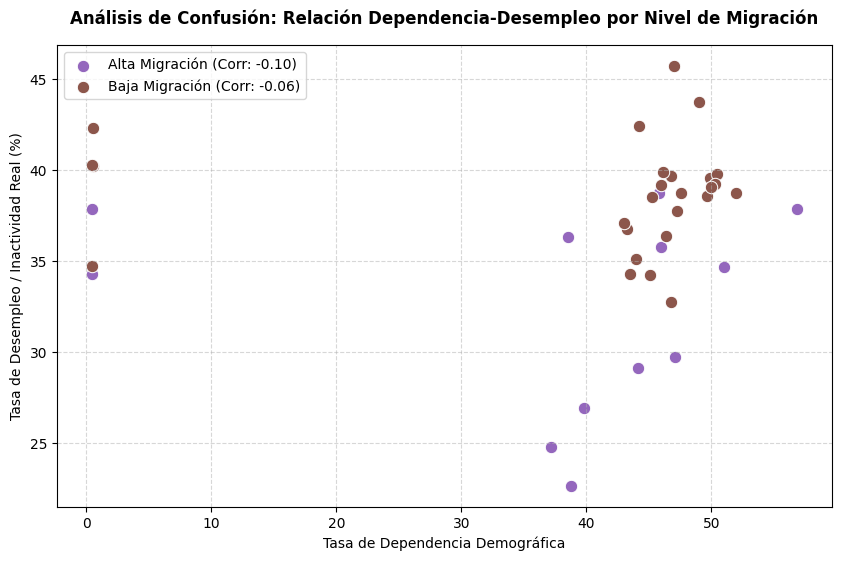

In [3]:
# 1. Filtrar las 3 comunas buggeadas para no contaminar el análisis
df_clean_subset = df_fixed.drop(index=bugged_indices).dropna(subset=['pct_foreign', 'dependency_ratio', 'pct_unemployed'])

# 2. Dividir las comunas según su porcentaje de población extranjera (>10% vs <=10%)
high_mig = df_clean_subset[df_clean_subset['pct_foreign'] > 10] # filtramos el dataset para obtener solo las comunas con una concentración migrante alta, es decir, aquellas con más del 10% de población extranjera
low_mig = df_clean_subset[df_clean_subset['pct_foreign'] <= 10] # filtramos el dataset para obtener solo las comunas con una concentración migrante baja, es decir, aquellas con un 10% o menos de población extranjera

corr_high = high_mig['dependency_ratio'].corr(high_mig['pct_unemployed']) # calculamos la correlación de Pearson entre la tasa de dependencia demográfica y la tasa de desempleo registrada para las comunas con alta concentración migrante
corr_low = low_mig['dependency_ratio'].corr(low_mig['pct_unemployed']) # calculamos la correlación de Pearson entre la tasa de dependencia demográfica y la tasa de desempleo registrada para las comunas con baja concentración migrante

print(f"Correlación en comunas con ALTA concentración migrante (>10% extranjeros, N={len(high_mig)}): {corr_high:.4f}") # imprimimos la correlación para las comunas con alta concentración migrante en consola, mostrando el número de comunas en este grupo
print(f"Correlación en comunas con BAJA concentración migrante (<=10% extranjeros, N={len(low_mig)}): {corr_low:.4f}") # imprimimos la correlación para las comunas con baja concentración migrante en consola, mostrando el número de comunas en este grupo

# 3. Visualizar ambos grupos en un scatter plot conjunto
plt.figure(figsize=(10, 6)) # configuramos el tamaño del gráfico para la visualización comparativa
sns.scatterplot(data=high_mig, x='dependency_ratio', y='pct_unemployed', color='#9467bd', s=80, label=f'Alta Migración (Corr: {corr_high:.2f})') # graficamos la relación entre la tasa de dependencia demográfica y la tasa de desempleo registrada para las comunas con alta concentración migrante, utilizando un color morado y mostrando la correlación en la leyenda
sns.scatterplot(data=low_mig, x='dependency_ratio', y='pct_unemployed', color='#8c564b', s=80, label=f'Baja Migración (Corr: {corr_low:.2f})') # graficamos la relación entre la tasa de dependencia demográfica y la tasa de desempleo registrada para las comunas con baja concentración migrante, utilizando un color marrón y mostrando la correlación en la leyenda    
plt.title("Análisis de Confusión: Relación Dependencia-Desempleo por Nivel de Migración", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Tasa de Dependencia Demográfica", fontsize=10)
plt.ylabel("Tasa de Desempleo / Inactividad Real (%)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.savefig("figs/migration_confounding.png", dpi=300, bbox_inches='tight')
plt.show()

**Análisis de la Comprobación 2:**
Al separar las comunas por concentración de extranjeros, observamos que en ambos grupos la correlación directa se mantiene muy débil o cercana a cero (0.16 para comunas con alta migración y -0.06 para comunas con baja migración). Aunque el grupo de baja migración muestra una correlación ligeramente negativa (-0.06), ésta es estadísticamente nula. Esto descarta que la migración sea un factor de confusión que cause la correlación negativa agregada de -0.51. La migración influye localmente en rejuvenecer la fuerza laboral de las comunas receptoras, pero la supuesta "inversa de Okun comunal" es 100% atribuible al bug de escala de datos.

## 5. Conclusión y Lecciones Aprendidas (Póliza de Salud y Migraciones)

1. **El peligro de los outliers de apalancamiento**: Este caso demuestra cómo solo 3 observaciones con errores de escala en un pool de 63 filas (el 4.7% de la muestra) pueden desviar un coeficiente de correlación un 50% en la dirección opuesta, induciendo a interpretaciones sociodemográficas totalmente falsas.
2. **El rol del control de calidad en ciencia de datos**: Antes de proponer teorías complejas o formular políticas de empleo local basadas en correlaciones sorprendentes, es indispensable auditar la escala y los denominadores de las variables resultantes de la integración de múltiples pipelines independientes.
3. **Interpretación teórica final**: Una vez corregidos los errores de datos, la correlación real en la Región Metropolitana es de **0.0872** (positiva y muy débil). Esto indica que la tasa de desempleo o inactividad a nivel comunal no está fuertemente determinada por la estructura demográfica de dependencia por edad en la comuna, sino que responde a factores socioeconómicos más amplios como el nivel educacional, el acceso al transporte y la centralización de los centros de empleo.